# EXPLORATORY DATA ANALYSIS (EDA):

## Project Context:

This notebook contains the Exploratory Data Analysis (EDA) for the Marketing Campaign Analysis and Optimization project.
The dataset captures performance metrics across multiple marketing campaigns, including spend, impressions, clicks, conversions, and revenue related measures, along with key categorical dimensions such as channel, region, and campaign identifiers.

This EDA is conducted after feature engineering and focuses on validating data quality, understanding metric behavior, and identifying performance patterns and risks.

#### Objective:

The very objective of this EDA notebook is to:
- Validate the integrity and reliability of the engineered features
- Understand the distribution and behavior of key performance metrics
- Examine relationships and tradeoffs between cost, volume, and efficiency
- Identify segment-level performance differences and risks
- Surface insights that can inform further analysis or modeling
- This analysis is descriptive and diagnostic, not prescriptive.

#### Business Questions Addressed:

This notebook aims to answer the following high-level questions:
- Can the campaign performance data be trusted for analysis?
- How do core marketing metrics behave in isolation and in relation to one another?
- What cost-efficiency tradeoffs are observable in the data?
- How does performance vary across channels, regions, and campaign segments?
- Where are the major data risks, outliers, or instability points?

### My Goal: Explore data patterns & insights:

#### Tasks:
- Distribution plots (budget, impressions, clicks, conversions)
- Correlations between metrics (budget vs conversions, CTR vs CR)
- Channel-level comparisons (Email vs SEO vs Social vs Display Ads)
- Identify trends (monthly conversions, CTR over time)
- Document key anomalies (e.g., campaigns with high spend but low CR)
- Im still thinking what other things to address at this point

#### Dataset Description:

- Data domain: Marketing campaign performance data cleaned and featured 
- Granularity: Campaign-level
- Time range: (still to be confirmed in Phase 1)
- Core metric types:
    - Volume metrics (impressions, clicks, spend, revenue)
    - Efficiency metrics (CTR, CPC, CPA, ROAS, ROI)
- Key dimensions:
    - Channel
    - Region
    - Campaign / campaign type
    - Time (date)

### Import Libraries:

In [2]:
# Libraries

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

pd.options.display.float_format = '{:,.4f}'.format

### Ingest Data as DF:

In [3]:
# INGEST DATA

df = pd.read_csv("../data/processed/marketing_campaign_2024_2025_processed.csv")

## PHASE 1: Dataset Overview & Structural Integrity

Establish why this dataset and its structure can be trusted

### Dataset Shape + Columnnames andd dtypes:

In [4]:
# Dataset Shape + Columnnames andd dtypes

print(df.shape)
df.info()

# Assess distributional shape of core metrics:
    # Row count is reasonable for campaign level analysis
    # Column count aligns with expected metrics and dimensions
    # Metric columns are numeric
    # Categorical dimensions are object or category
    # Date column is not datetime -- needs to be addressed

(1831, 42)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1831 entries, 0 to 1830
Data columns (total 42 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   campaign_id                1831 non-null   object 
 1   campaign_name              1831 non-null   object 
 2   start_date                 1831 non-null   object 
 3   end_date                   1831 non-null   object 
 4   channel                    1831 non-null   object 
 5   region                     1831 non-null   object 
 6   impressions                1831 non-null   int64  
 7   clicks                     1831 non-null   int64  
 8   conversions                1831 non-null   int64  
 9   spend_usd                  1831 non-null   float64
 10  revenue_usd                1831 non-null   float64
 11  target_audience            1831 non-null   object 
 12  product_category           1831 non-null   object 
 13  device                     1831 non-n

##### Sample rows check:

In [5]:
# sample rows lead
df.head()

,campaign_id,campaign_name,start_date,end_date,channel,region,impressions,clicks,conversions,spend_usd,...,profit_margin,impressions_to_conversion,click_to_conv_ratio,midpoint_month,season_label,engagement_rate_1000,rev_per_1000,roi_flag,midpoint_date,funnel_issue_flag
0,2024_0001,Campaign_2024_0001,2024-05-16,2024-08-16,Google Ads,South America,28252,5609,5609,"39,193.4300",...,0.5040,0.1985,1.0000,7,Summer,397.0692,"2,796.8901",0,2024-07-01 00:00:00,False
1,2024_0002,Campaign_2024_0002,2024-04-06,2024-10-13,Google Ads,Asia,89608,83584,26865,"17,291.5300",...,0.6533,0.2998,0.3214,7,Summer,"1,232.5797",556.5188,1,2024-07-10 00:00:00,False
2,2024_0003,Campaign_2024_0003,2024-05-08,2024-11-27,Facebook Ads,Europe,37853,37853,37853,"6,729.6300",...,0.8932,1.0000,1.0000,8,Summer,"2,000.0000","1,664.8953",1,2024-08-17 12:00:00,False
3,2024_0004,Campaign_2024_0004,2024-01-28,2024-08-03,Google Display Network,Africa,10577,10577,10577,"15,077.5800",...,0.8867,1.0000,1.0000,5,New Year,"2,000.0000","12,584.5429",1,2024-05-01 00:00:00,False
4,2024_0005,Campaign_2024_0005,2024-02-06,2024-08-23,Facebook Ads,Asia,84039,56010,11283,"16,877.6900",...,0.8834,0.1343,0.2014,5,New Year,800.7354,"1,722.2598",1,2024-05-15 12:00:00,False


In [6]:
# sample rows tails
df.tail()

,campaign_id,campaign_name,start_date,end_date,channel,region,impressions,clicks,conversions,spend_usd,...,profit_margin,impressions_to_conversion,click_to_conv_ratio,midpoint_month,season_label,engagement_rate_1000,rev_per_1000,roi_flag,midpoint_date,funnel_issue_flag
1826,2024_JD_0778,Campaign_2024_JD_0778,2024-12-30,2025-01-06,TikTok Ads,Africa,137632,14988,1415,"11,741.4900",...,0.7097,0.0103,0.0944,1,Holiday Peak,119.1801,293.8521,1,2025-01-02 12:00:00,False
1827,2024_JD_0777,Campaign_2024_JD_0777,2024-12-30,2025-01-06,Google Ads,Africa,134951,15552,842,"8,453.1100",...,0.5481,0.0062,0.0541,1,Holiday Peak,121.4811,138.6027,0,2025-01-02 12:00:00,False
1828,2024_JD_0775,Campaign_2024_JD_0775,2024-12-30,2025-01-06,TikTok Ads,South America,133585,17131,1145,"41,260.7500",...,0.5578,0.0086,0.0668,1,Holiday Peak,136.8118,698.5163,0,2025-01-02 12:00:00,False
1829,2024_JD_0776,Campaign_2024_JD_0776,2024-12-30,2025-01-06,TikTok Ads,South America,133585,17131,1145,"41,260.7500",...,0.5578,0.0086,0.0668,1,Holiday Peak,136.8118,698.5163,0,2025-01-02 12:00:00,False
1830,2024_JD_0774,Campaign_2024_JD_0774,2024-12-30,2025-01-06,Google Ads,South America,132734,18486,4210,"23,056.1000",...,0.4193,0.0317,0.2277,1,Holiday Peak,170.9886,299.1173,0,2025-01-02 12:00:00,False


In [7]:
# so far the values align with column meaning
# No obvious placeholder values
# Metrics appear within reasonable ranges
# No unexpected null patterns at the beginning or end

### Date Coverage:

In [8]:
# Date Coverage

# df["start_date"].min(), df["start_date"].max()  # check startdate
# df["end_date"].min(), df["end_date"].max()  # check end_date
# df["month"].min(), df["month"].max()  # check month
# df["start_month"].min(), df["start_month"].max()  # check start_month
# df["end_month"].min(), df["end_month"].max()  # check end_month
# df["year"].min(), df["year"].max()  # check year

summary = {
    col: {"min": df[col].min(), "max": df[col].max()}
    for col in [
        "start_date", "end_date", "month",
        "start_month", "end_month", "campaign_duration_days", "year"
    ]
}

pd.DataFrame(summary).T

# Start and end dates make sense for the project
# Coverage aligns with expectations from the data source
# No future or implausible dates
# i want to ceck if aggregations will not misleading

,min,max
start_date,2024-01-01,2025-06-30
end_date,2024-07-02,2025-12-31
month,1,12
start_month,1,12
end_month,1,12
campaign_duration_days,4,364
year,2024,2025


##### Convert date columns to datetime:

In [9]:
# Convert date columns to datetime

date_cols = ["start_date", "end_date", "midpoint_date"]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')  # coerce invalid parses to NaT

# Confirm conversion
df[date_cols].info()
df[date_cols].head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1831 entries, 0 to 1830
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   start_date     1831 non-null   datetime64[ns]
 1   end_date       1831 non-null   datetime64[ns]
 2   midpoint_date  1831 non-null   datetime64[ns]
dtypes: datetime64[ns](3)
memory usage: 43.0 KB


,start_date,end_date,midpoint_date
0,2024-05-16,2024-08-16,2024-07-01 00:00:00
1,2024-04-06,2024-10-13,2024-07-10 00:00:00
2,2024-05-08,2024-11-27,2024-08-17 12:00:00
3,2024-01-28,2024-08-03,2024-05-01 00:00:00
4,2024-02-06,2024-08-23,2024-05-15 12:00:00


##### Date Parsing:

In [10]:
# Date Parsing Validation:

# check min & max dates per date column

date_cols_check = {
    col: {"min": df[col].min(), "max": df[col].max()}
    for col in ["start_date", "end_date", "midpoint_date"]
}

pd.DataFrame(date_cols_check).T

,min,max
start_date,2024-01-01 00:00:00,2025-06-30
end_date,2024-07-02 00:00:00,2025-12-31
midpoint_date,2024-04-05 12:00:00,2025-09-28


##### Date Parsing Validation:

In [11]:
# Date Parsing Validation:

# cath the imposible dates + basic duration sanity check

invalid_campaigns = df[df["end_date"] < df["start_date"]]

print("Invalid campaigns (end before start):", invalid_campaigns.shape[0])

# This ensures all campaigns have start_date ≤ end_date
# 0 results means its good to go

Invalid campaigns (end before start): 0


##### midpoint_date_computed:

In [12]:
# midpoint_date_computed:

# Compute midpoint from start_date and end_date
df['midpoint_date_computed'] = df['start_date'] + (df['end_date'] - df['start_date']) / 2

# Compare with existing midpoint_date
inconsistent_midpoints = df[df['midpoint_date'] != df['midpoint_date_computed']]

print("Number of campaigns with inconsistent midpoint_date:", inconsistent_midpoints.shape[0])

# Optional: inspect first few inconsistencies
inconsistent_midpoints[['campaign_id', 'start_date', 'end_date', 'midpoint_date', 'midpoint_date_computed']]

Number of campaigns with inconsistent midpoint_date: 0


,campaign_id,start_date,end_date,midpoint_date,midpoint_date_computed


##### midpoint_date_computed validation:

In [13]:
# midpoint_date_computed validation:

df['midpoint_date'] = df['midpoint_date_computed']
df.drop(columns=['midpoint_date_computed'], inplace=True)

# No result on created temporary table means midpoint_date is fully consistent with the start and end dates
# start_date, end_date, and midpoint_date properly parsed as datetime
# No inconsistencies or errors in midpoint calculation

### Duplicate Checks:


In [14]:
# Duplicate Checks:

df.duplicated().sum()

# Duplicate rows checked explicitly, no duplicated records detected.
# Duplicate count is zero (Nulls ≠ duplicates)
# No unintended row duplication that would inflate metrics
# looks good to me

np.int64(0)

### Numeric Integrity + Metric sanity checking:

In [15]:
# Numeric Integrity + Metric sanity checking:

numeric_cols = df.select_dtypes(include='number').columns

df[numeric_cols].describe().T

# Do numeric features look structurally and mathematically sane?
# Does this data make sense to analyze?

# this dataset is structurally analyzable, but it clearly contains:
    # Heavy skew
    # Extreme outliers
    # Ratio inflation artifacts
    # Binary felds leaking into numeric summaries (roi_flag is binary but appears in numeric summaries - should be bolean tho)

,count,mean,std,min,25%,50%,75%,max
impressions,"1,831.0000","74,943.7788","50,331.1146","1,034.0000","35,807.5000","67,696.0000","98,318.0000","199,027.0000"
clicks,"1,831.0000","21,113.1491","20,284.3329",86.0000,"5,755.5000","13,487.0000","30,780.0000","89,352.0000"
conversions,"1,831.0000","12,952.8471","16,535.2505",4.0000,962.0000,"4,424.0000","20,834.0000","79,692.0000"
spend_usd,"1,831.0000","25,733.9855","13,839.3821","1,066.1100","14,339.4600","25,931.8900","37,271.8250","49,908.4500"
revenue_usd,"1,831.0000","69,212.1397","41,545.3485","1,098.6600","35,753.5600","65,667.7700","102,387.8550","172,113.1500"
year,"1,831.0000","2,024.2731",0.4457,"2,024.0000","2,024.0000","2,024.0000","2,025.0000","2,025.0000"
campaign_duration_days,"1,831.0000",125.0535,85.4753,4.0000,51.5000,117.0000,187.0000,364.0000
month,"1,831.0000",6.3736,3.5501,1.0000,3.0000,6.0000,10.0000,12.0000
quarter,"1,831.0000",2.4473,1.1387,1.0000,1.0000,2.0000,4.0000,4.0000
start_month,"1,831.0000",6.3736,3.5501,1.0000,3.0000,6.0000,10.0000,12.0000


### Categorical Structure + Cardinality Check:

##### Categorical:

In [16]:
# Category = df[["impressions", "clicks", "conversions"]].describe().T

cat_summary = df.select_dtypes(include=["object", "category"]).describe().T

cat_summary

# so far clear identifiers
# Reasonable category counts
# No obvious cardinality traps (except IDs, thats expected)

,count,unique,top,freq
campaign_id,1831,1831,2024_0001,1
campaign_name,1831,1831,Campaign_2024_0001,1
channel,1831,5,Email,389
region,1831,5,Africa,380
target_audience,1831,3,Adults,620
product_category,1831,7,Home,376
device,1831,3,Mobile,647
data_source,1831,3,H2_2024,831
season_label,1831,4,Summer,514


In [17]:
# campaign_id, campaign_name - perfect one-to-one identifiers & no dups They have high cardinality
# start_date, end_date, midpoint_date - High cardinality (hundreds of unique values) & end_date = 2024-12-31 appears 304 times
    # start dates more spread
    # campaigns ended at year-end (batch termination)
    # Date columns parsed to datetime; categorical summary used only to inspect cardinality patterns.
    # should be datetime, not categorical (i believe i had issues converting this last time)
# channel, region, target_audience, product_category, device - so far has no exploding categories 
    # these core dimensions have manageable cardinality and are suitable for grouping analysis.
# data_source, season_label - are metadata they have low cardinality
    # Identifier columns or metadata should be excluded from aggregation

##### Volume & Exposure Metrics:

In [18]:
# Volume & Exposure Metrics

Category = df[["impressions", "clicks", "conversions"]].describe().T

Category

# Distributional skew expected due to campaign scale differences
# if you look closely its wihin the reasonable magnitudes
# & logical ordering holds (impressions > clicks > conversions)
# ong right tails (expected) + No zero or negative values

,count,mean,std,min,25%,50%,75%,max
impressions,"1,831.0000","74,943.7788","50,331.1146","1,034.0000","35,807.5000","67,696.0000","98,318.0000","199,027.0000"
clicks,"1,831.0000","21,113.1491","20,284.3329",86.0000,"5,755.5000","13,487.0000","30,780.0000","89,352.0000"
conversions,"1,831.0000","12,952.8471","16,535.2505",4.0000,962.0000,"4,424.0000","20,834.0000","79,692.0000"


##### Financial Metrics:

In [19]:
# Financial Metrics

FinCategory = df[["spend_usd", "revenue_usd", "profit"]].describe().T

FinCategory

# Profit distribution is asymmetric, it means inflated by high-performing campaigns
# Revenue consistently ≥ spend on median
# No zero spend rows (important for ratio stability)
# Profit has heavy right skew

,count,mean,std,min,25%,50%,75%,max
spend_usd,"1,831.0000","25,733.9855","13,839.3821","1,066.1100","14,339.4600","25,931.8900","37,271.8250","49,908.4500"
revenue_usd,"1,831.0000","69,212.1397","41,545.3485","1,098.6600","35,753.5600","65,667.7700","102,387.8550","172,113.1500"
profit,"1,831.0000","43,478.1543","39,149.4354","-45,604.0400","13,206.9300","37,218.6700","71,677.8300","148,270.8000"


##### Time & Duration:

In [20]:
# Time & Duration

DCategory = df[["year", "month", "quarter", "start_month", "end_month", "midpoint_month", "campaign_duration_days"]].describe().T

DCategory

# Coverage year of only 2024–2025
# Month columns are categorical encoded as numeric -- done with this
# Month-based fields treated as categorical/time dimensions, not numeric measures -- done with this

,count,mean,std,min,25%,50%,75%,max
year,"1,831.0000","2,024.2731",0.4457,"2,024.0000","2,024.0000","2,024.0000","2,025.0000","2,025.0000"
month,"1,831.0000",6.3736,3.5501,1.0000,3.0000,6.0000,10.0000,12.0000
quarter,"1,831.0000",2.4473,1.1387,1.0000,1.0000,2.0000,4.0000,4.0000
start_month,"1,831.0000",6.3736,3.5501,1.0000,3.0000,6.0000,10.0000,12.0000
end_month,"1,831.0000",10.1447,2.1654,1.0000,9.0000,11.0000,12.0000,12.0000
midpoint_month,"1,831.0000",8.3812,2.4948,1.0000,6.0000,8.0000,11.0000,12.0000
campaign_duration_days,"1,831.0000",125.0535,85.4753,4.0000,51.5000,117.0000,187.0000,364.0000


##### Rate & Ratios:

In [21]:
# Rate & Ratios:

RRCategory = df[["ctr", "conversion_rate", "click_to_conv_ratio", "impressions_to_conversion"]].describe().T

RRCategory

# All within logical bounds of 0 and 1 [0, 1]
# No values >1
# Median more informative than mean
# Rate metrics analyzed using median/quantiles rather than mean.

,count,mean,std,min,25%,50%,75%,max
ctr,"1,831.0000",0.4318,0.4016,0.0015,0.0834,0.1500,0.9600,1.0000
conversion_rate,"1,831.0000",0.5180,0.4020,0.0005,0.1511,0.2946,1.0000,1.0000
click_to_conv_ratio,"1,831.0000",0.5180,0.4020,0.0005,0.1511,0.2946,1.0000,1.0000
impressions_to_conversion,"1,831.0000",0.3209,0.3875,0.0002,0.0115,0.0814,0.6324,1.0000


##### ROI / Efficiency Metrics:

In [22]:
# ROI / Efficiency Metrics:

RECategory = df[["roi", "roas", "cpc", "cpm", "cpa"]].describe().T

RECategory

# Negative ROI exists, thats ok
# ROAS mirrors ROI + 1
# Extreme outliers:
    # ROI max = 132
    # CPC max = 561
    # CPA max = 8,781
# outliers will be handled via robust statistics and/or log scale
# most likely a very small denominators (low spend, few clicks/conversions) this greatly affects the mean

,count,mean,std,min,25%,50%,75%,max
roi,"1,831.0000",3.3049,8.0164,-0.9736,0.6634,1.5918,2.4178,132.4438
roas,"1,831.0000",4.3049,8.0164,0.0264,1.6634,2.5918,3.4178,133.4438
cpc,"1,831.0000",5.6057,20.5978,0.0253,0.6441,1.6132,4.2728,561.8712
cpm,"1,831.0000",817.8558,"1,936.6498",7.2564,180.3652,369.9433,744.8936,"31,726.2959"
cpa,"1,831.0000",46.9226,261.0013,0.0316,1.0507,4.1925,23.5973,"8,781.2650"


##### Revenue Density Metrics:

In [23]:
# ROI / Efficiency Metrics:

RevCategory = df[["revenue_per_click", "revenue_per_conversion", "rev_per_1000"]].describe().T

RevCategory

# No impossible negatives
# theres hhis severe long tails (order-of-magnitude jumps)
# A small number of high-value conversions dominate averages
# Revenue-per-unit metrics exhibit extreme skew
# analysis focuses on distributional shape, not central tendency.

,count,mean,std,min,25%,50%,75%,max
revenue_per_click,"1,831.0000",13.9847,43.8671,0.0133,1.7924,4.2187,10.1933,"1,038.0850"
revenue_per_conversion,"1,831.0000",120.2503,740.4753,0.0344,3.0650,11.4798,58.2574,"24,718.7000"
rev_per_1000,"1,831.0000","2,421.7802","6,115.1607",11.5347,439.9562,943.8065,"2,045.8426","84,749.4754"


##### Margin:

In [24]:
# Margin:

MCategory = df["profit_margin"].describe()

MCategory

# Negative margins exist (it occurs when revenue ≪ spend)
# theres an extremely negative values at (-36) (Mathematically valid but analytically dangerous)
# Profit margin clipped or log-transformed for visualization only

count   1,831.0000
mean        0.2964
std         1.7108
min       -36.8881
25%         0.3988
50%         0.6142
75%         0.7074
max         0.9925
Name: profit_margin, dtype: float64

##### Binary Leakage:

In [25]:
# Binary Leakage:

LCategory = df["roi_flag"].describe()

LCategory

# Appears in numeric summaries
# Values are clean with 0 & 1 
# Convert to boolean
# Binary flags mmust be excluded from numeric distribution analysis.

count   1,831.0000
mean        0.4997
std         0.5001
min         0.0000
25%         0.0000
50%         0.0000
75%         1.0000
max         1.0000
Name: roi_flag, dtype: float64

### PHASE 1: Summary

This phase validated the structural, mathematical, and semantic integrity of the dataset.
Both numeric and categorical features were inspected to confirm correctness, consistency, and analytical readiness.

Expected characteristics of marketing data were observed, including heavy skew, long-tailed distributions, and the presence of outliers, particularly in cost, efficiency, and revenue-based metrics. These behaviors are documented and intentionally not corrected at this stage.

No outlier removal, normalization for modeling, optimization, ranking, or causal assumptions were performed in this phase.

Conclusion: The dataset is structurally sound and analytically trustworthy, with no integrity issues blocking further exploratory analysis.
also note: Distributional behavior is noted here for integrity validation; detailed distribution analysis begins in Phase 2.

In [26]:
print(df.shape)
df.info()

(1831, 42)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1831 entries, 0 to 1830
Data columns (total 42 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   campaign_id                1831 non-null   object        
 1   campaign_name              1831 non-null   object        
 2   start_date                 1831 non-null   datetime64[ns]
 3   end_date                   1831 non-null   datetime64[ns]
 4   channel                    1831 non-null   object        
 5   region                     1831 non-null   object        
 6   impressions                1831 non-null   int64         
 7   clicks                     1831 non-null   int64         
 8   conversions                1831 non-null   int64         
 9   spend_usd                  1831 non-null   float64       
 10  revenue_usd                1831 non-null   float64       
 11  target_audience            1831 non-null   object        


## PHASE 2: Data Quality & Risk Assessment:

Identify fragile or biased data points that could distort insights

### MIssing Values:

In [27]:
# MIssing Values:

# Compute % of missing values per column
missing_pct = df.isna().mean() * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

missing_pct

# yep no missing values

Series([], dtype: float64)

### Zero-Heavy Metrics:

In [28]:
# Zero-Heavy Metrics:

# Metrics where zeros may distort averages
numeric_cols = df.select_dtypes(include='number').columns # filter only numeric dtypes dataset

zero_pct = (df[numeric_cols] == 0).mean() * 100 # get the mean * 100  
zero_pct = zero_pct[zero_pct > 0].sort_values(ascending=False) # filter and get only > 0 counts of 0 values

zero_pct

# roi_flag with 50.0273 is expected, roi_flag should be bolean
# roi_flag will be excluded from viz and irect analysis

roi_flag   50.0273
dtype: float64

### Infinite + Undefined Values:

In [29]:
# Infinite + Undefined Values:

# Check for divisions producing Inf or NaN
inf_values = df[numeric_cols].isin([np.inf, -np.inf]).sum() # filter the sum of only numeric with redundant cont values
inf_values = inf_values[inf_values > 0] # get only values> 0

inf_values

# no inf nor undefined values pulled
# inf & undef values needs specialized handling or execution that needs to be addressed beforehand / before any anlyses 

Series([], dtype: int64)

### Skewed Metrics:

In [38]:
# Skewed Metrics:

# Rough check: mean vs median for numeric features
median_vs_mean = df[numeric_cols].median() / df[numeric_cols].mean()
top5 = median_vs_mean.sort_values(ascending=True) #.head(5)

top5

# this stage only shows how skewed a feature is but not its direction explicitly
    # = 1.0 = symmeric
    # > 1.0 = median > mean, meaning median is much larger than the mean and thi is a left skewed data (-)
    # < 1.0 = mean pulls up by large values then the median, thi is right skewd (+)

# extremely left skewed metrix (-):
    # mean is freated than the mean
    # profit_margin & end_month are both right skewed / end_month is not a distribution
    # spend_usd with 1.007 & year with 0.9999 is simetric by definition / year is not a distribution
    # the rest starting from midpoint_month are all right skewed(+) / from little to extreme right skewed
    
# These are the ones that matters most & they are all severely right skewed(+):
    # cpa                         0.0893
    # revenue_per_conversion      0.0955
    # impressions_to_conversion   0.2536
    # cpc                         0.2878
    # revenue_per_click           0.3017
    # ctr                         0.3473
    # roi                         0.4817
    # roas                        0.6021
    # conversion_rate             0.5688
    # click_to_conv_ratio         0.5688
# Long tail of very large values & Long tail of very large values well this is expected
# Median ≪ Mean
# A small number of very large values inflate the mean
# mean is misleading at this point unless normalized or Median is used instead or perhaps use percetiles

# these metrix are moderetely to little rightly skewed, meaning they less extreme and resides near the 0 value
    # clicks                      0.6388
    # impressions                 0.9033
    # revenue_usd                 0.9488
    # profit                      0.8560
    # campaign_duration_days      0.9356

# date data not analyticaly skewed
    # month                       0.9414
    # start_month                 0.9414
    # quarter                     0.8172
# this is expected from date dataas these are not disribution

# Special case: roi_flag = 0.0000 is binary with only 0 & 1 values

roi_flag                    0.0000
cpa                         0.0893
revenue_per_conversion      0.0955
impressions_to_conversion   0.2536
cpc                         0.2878
revenue_per_click           0.3017
conversions                 0.3415
ctr                         0.3473
engagement_rate_1000        0.3781
rev_per_1000                0.3897
cpm                         0.4523
roi                         0.4817
click_to_conv_ratio         0.5688
conversion_rate             0.5688
roas                        0.6021
clicks                      0.6388
quarter                     0.8172
profit                      0.8560
impressions                 0.9033
campaign_duration_days      0.9356
month                       0.9414
start_month                 0.9414
revenue_usd                 0.9488
midpoint_month              0.9545
year                        0.9999
spend_usd                   1.0077
end_month                   1.0843
profit_margin               2.0723
dtype: float64

### Temporal Sanity Check:

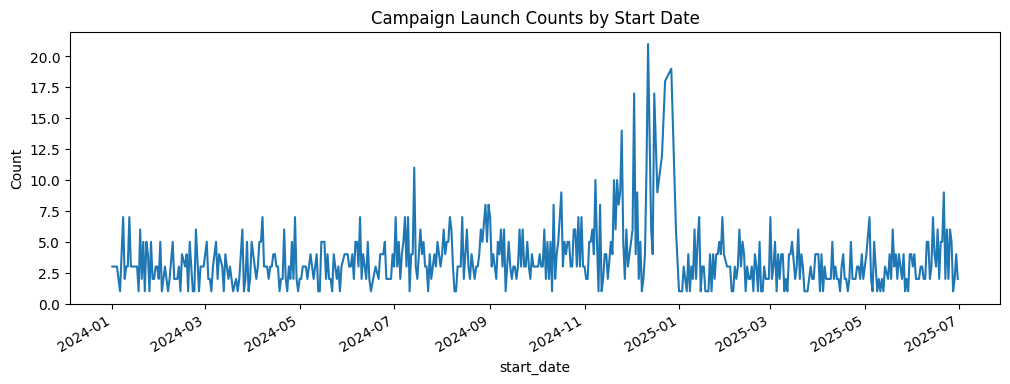

In [39]:
# Temporal Sanity Check:
    
# Daily activity counts (or weekly for aggregation)
daily_counts = df.groupby('start_date').size() # counts campaighns starts on each date explicitly
daily_counts.describe() # stats command that mean campaigns per day,nim & max launches and distri spread 


# Optionally visualize spikes/drops
plt.figure(figsize=(12,4))
daily_counts.plot()

plt.title("Campaign Launch Counts by Start Date")
plt.ylabel("Count")

plt.show()

# addressing date trends assumptions of the data set (i trust this dataset enough to learn from it)
# No extended temporal gaps observed, date coverage is continuous
    # no gaps / no missing date
    # No abnormal clustering suggesting duplicated campaign records
    # No silent aggregation errors
    # data is aggregated from start_date not parsed from early months and dense months conserving authenticity
# Expected seasonal spike observed during late Q4 / early Q1.
# dataset is from april 2024 to July 2025
# temporal: the data behaves like time actualy happened and it flows accordinly based on the reality of normal human behavior
# behavior of the dataset specialy the sharp spike during holidays then drop back o baseline and stabilized is noy suspicioss thus realistic and true

# THIS MEANS: I can trust downstream EDA and modeling to not be time-corrupted.

In [41]:
# Temporal sanity check confirms continuous and realistic time behavior.
# No extended gaps or abnormal clustering were observed.
# A pronounced but expected seasonal increase appears during late Q4–early Q1,
# likely driven by holiday campaign activity.
# Postholiday volumes return to baseline, indicating normal operational flow.
# Dataset is temporally consistent and suitable for modeling.

### Duration Sanity:

In [40]:
# Check for campaigns with unusually short/long durations
df['campaign_duration_days'].describe()

# min = 4 days wwhile max = 364 days (quite a large gap in duration)
# Median is 117 days
# mean is 125 days & is slightly bigger than the median making this a Right skewd data(+)
# IQR: 51.5 – 187 days

# Campaign durations span very short bursts (≈4 days) to near full-year campaigns (≈12 months)
# The mean exceeds the median, indicating a right-skewed distribution driven by long-running campaigns
    # No values fall outside logical bounds:
        # No zero or negative durations
        # No durations exceeding one year

count   1,831.0000
mean      125.0535
std        85.4753
min         4.0000
25%        51.5000
50%       117.0000
75%       187.0000
max       364.0000
Name: campaign_duration_days, dtype: float64

Campaign durations vary widely and exhibit right skew, with values ranging from short-term initiatives to near year-long campaigns. This variability is expected and will be explicitly accounted for in later analyses through normalization or rate-based comparisons where appropriate.

### PHASE 2: Summary

This phase evaluated potential data quality risks that could bias or destabilize downstream exploratory analysis.
The objective was risk identification and documentation, not correction or optimization.

- No missing values were detected across the dataset.
- No infinite or undefined values were found in any numeric or engineered metric
- Several ratio and efficiency metrics exhibit structural zero inflation, driven by zero clicks or conversions rather than data errors.
- The roi_flag variable is binary in nature and will be treated as categorical rather than numeric
- Many core performance metrics (cost, revenue, efficiency, ROI-based metrics) are severely right-skewed, with long tails of extreme values
- Mean values are not representative for most ratio-based metrics; medians and percentiles are more appropriate

These behaviors are expected for marketing performance data and do not indicate corruption or leakage.

##### Temporal Sanity Check:
- Campaign data spans April 2024 to July 2025 with continuous coverage.
- No unexplained gaps, abnormal clustering, or duplicated launch patterns were detected.
- Seasonal behavior is realistic, with a clear spike during late Q4–early Q1 followed by normalization.
- Campaign duration ranges from 4 to 364 days, with right-skew driven by long-running campaigns.
- All durations fall within logical bounds.

The dataset is structurally sound, valid, and temporally coherent. it behaves and reflects real operational activity over time
All known analytical risks: zero inflation, skewness, and duration variability are explicitly but carefully documented.
Therefore, there are no integrity issues blocking further exploratory analysis.

#### Explicit Metric Classes Note:

##### Metric Classes:

- **Volume metrics:** impressions, clicks, conversions, spend_usd, revenue_usd
- **Rate / ratio metrics:** ctr, conversion_rate, roi, roas
- **Unit economics / efficiency:** cpc, cpa, cpm
- **Revenue intensity / derived metrics:** revenue_per_click, revenue_per_conversion, rev_per_1000
- **Time / duration metrics:** campaign_duration_days, start_month, end_month, midpoint_month


#### Grain Confirmation Note:

##### Dataset Grain

All metrics are measured at the **campaign level**.  
No row represents sub-campaign, creative, or daily observations.  
This confirms that aggregation or grouping in later analyses will be consistent with the dataset's grain.


#### Flag Skewed Metrics:

Unsuitable for Mean-Based Ranking

In [49]:
# Flag Skewed:

# Metrics unsuitable for mean-based ranking due to skew / zero-inflation
skewed_metrics = [
    'cpa', 'cpc', 'revenue_per_click', 'revenue_per_conversion', 'roi', 'roas'
]

# Example note
print("Metrics flagged for robust statistical treatment:", skewed_metrics)


Metrics flagged for robust statistical treatment: ['cpa', 'cpc', 'revenue_per_click', 'revenue_per_conversion', 'roi', 'roas']


#### Skewed Metrics Warning

The following metrics exhibit strong right skew and/or zero inflation and will not be ranked or compared using raw means:
- cpa
- cpc
- revenue_per_click
- revenue_per_conversion
- roi
- roas

Later analyses will use medians, percentiles, or log-transformations as appropriate.

#### Convert roi_flag to boolean:

Convert roi_flag to boolean and ensure date columns are datetime64

In [50]:
# Convert roi_flag:

# Boolean conversion
df['roi_flag'] = df['roi_flag'].astype(bool)

# Date columns (already parsed, but ensure type)
date_cols = ['start_date', 'end_date', 'midpoint_date']
df[date_cols] = df[date_cols].apply(pd.to_datetime)

In [51]:
# Type Validation:

df.dtypes[date_cols + ['roi_flag']]

# confirmed! great!

start_date       datetime64[ns]
end_date         datetime64[ns]
midpoint_date    datetime64[ns]
roi_flag                   bool
dtype: object